# Chapter 36 — Scientific Notation

> **Prerequisites:** ch022 (Natural Numbers), ch026 (Real Numbers), ch034 (Ratios and Proportions)  
> **You will learn:**
> - Scientific notation as controlled-exponent representation
> - Order of magnitude comparisons
> - How computers represent numbers in floating-point (sign, exponent, mantissa)
> - Significant figures and precision
> - Navigating the scale of the universe computationally
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Scientific notation expresses a number as `m × 10^e` where `1 ≤ |m| < 10` (the mantissa or significand) and `e` is an integer exponent. It is designed to make the scale of a number explicit and arithmetic on very large or very small numbers tractable.

**Why it matters:**
- The mass of a proton is 0.00000000000000000000000000167 kg — useless to read. `1.67 × 10^-27 kg` is exact and readable.
- GDP of the world: `~$10^14`. GDP of a single person: `~$10^4`. The ratio is `10^10`. Scientific notation makes ratios of scale immediate.
- IEEE 754 floating-point is scientific notation in base 2. Understanding the notation is the prerequisite for understanding floats.

**Significant figures:**  
In `3.14 × 10^2`, there are 3 significant figures. Trailing zeros before the decimal are ambiguous in plain notation (`100` could be 1, 2, or 3 sig figs). Scientific notation makes precision explicit.

**Common misconception:** Significant figures count *meaningful* digits, not decimal places. `0.00345` has 3 significant figures — the leading zeros are positional, not significant.

---

## 2. Intuition & Mental Models

**Geometric analogy — the ruler with sliding scale:**  
Think of scientific notation as a ruler where you first choose the scale (the exponent) and then read the position (the mantissa). The exponent tells you which ruler to use; the mantissa tells you where on that ruler you are.

**Computational analogy — floating-point register:**  
Think of a 64-bit float as a fixed number of bits for the exponent (11 bits → range ~10^±308) and bits for the mantissa (52 bits → ~15 decimal digits of precision). The exponent sets scale; the mantissa sets position within that scale.

**Order of magnitude:**  
Two numbers are in the same order of magnitude if their ratio is less than 10. The order of magnitude of x is `floor(log_10(|x|))`. This is the exponent in scientific notation.

**Recall from ch025 (Irrational Numbers):** We computed π to many decimal places. Scientific notation would express the error of a π approximation as e.g. `~10^-7` — immediately conveying the scale of accuracy without counting zeros.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_7264\23641955.py:52: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7264\23641955.py:52: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


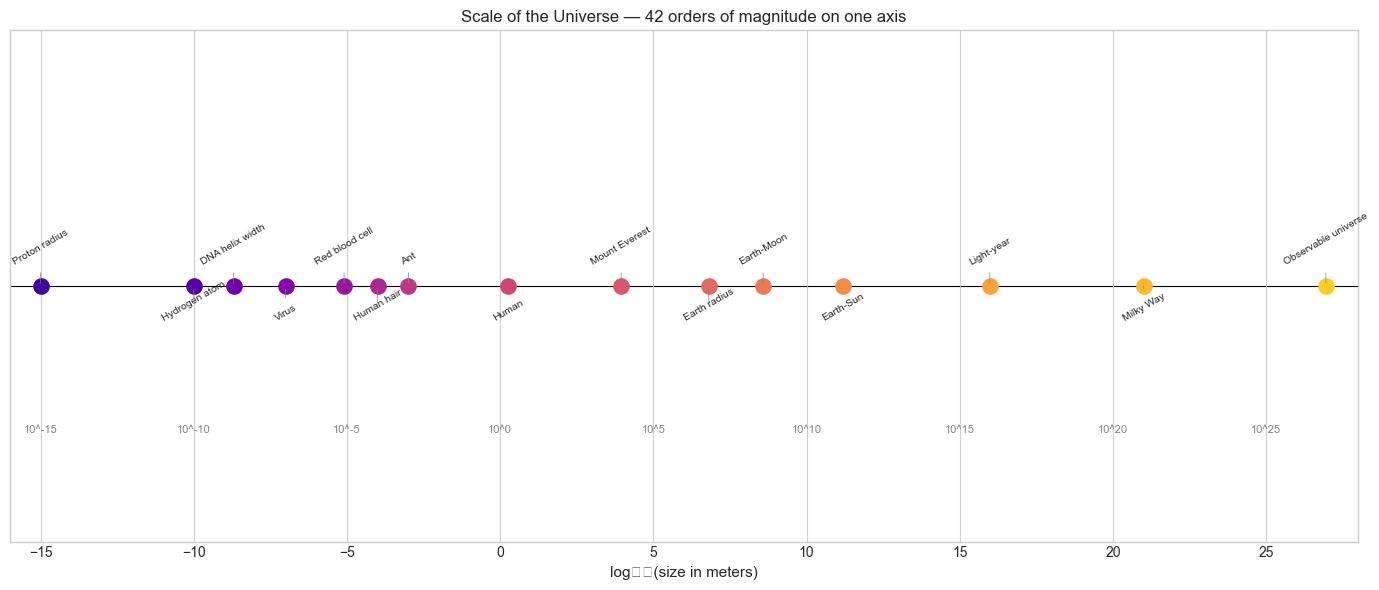

In [1]:
# --- Visualization: Scale of the universe on a logarithmic axis ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Physical quantities with their approximate scales (in meters or kg or seconds)
objects = {
    'Proton radius':     1e-15,
    'Hydrogen atom':     1e-10,
    'DNA helix width':   2e-9,
    'Virus':             1e-7,
    'Red blood cell':    8e-6,
    'Human hair':        1e-4,
    'Ant':               1e-3,
    'Human':             1.8,
    'Mount Everest':     8.8e3,
    'Earth radius':      6.4e6,
    'Earth-Moon':        3.8e8,
    'Earth-Sun':         1.5e11,
    'Light-year':        9.5e15,
    'Milky Way':         1e21,
    'Observable universe': 8.8e26,
}

names = list(objects.keys())
values = list(objects.values())
log_values = np.log10(values)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(names)))

for i, (name, lv, color) in enumerate(zip(names, log_values, colors)):
    ax.scatter(lv, 0, s=120, color=color, zorder=3)
    ax.annotate(name, (lv, 0),
                textcoords='offset points',
                xytext=(0, 15 if i % 2 == 0 else -25),
                ha='center', fontsize=7.5, rotation=30,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('log₁₀(size in meters)', fontsize=11)
ax.set_title('Scale of the Universe — 42 orders of magnitude on one axis', fontsize=12)
ax.set_yticks([])
ax.set_xlim(-16, 28)

# Add scale labels at every 5 orders
for exp in range(-15, 28, 5):
    ax.axvline(exp, color='lightgray', linewidth=0.5, linestyle='--')
    ax.text(exp, -0.03, f'10^{exp}', ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Scientific notation:**
```
x = m × 10^e
where 1 ≤ |m| < 10, e ∈ ℤ
```

**Converting to scientific notation:**
```
e = floor(log_10(|x|))
m = x / 10^e
```

**Arithmetic in scientific notation:**
```
Multiplication: (m₁ × 10^e₁) × (m₂ × 10^e₂) = (m₁ × m₂) × 10^(e₁+e₂)
Division:       (m₁ × 10^e₁) / (m₂ × 10^e₂) = (m₁ / m₂) × 10^(e₁-e₂)
Addition:       requires aligning exponents first
```

**Order of magnitude:**
```
OOM(x) = floor(log_10(|x|))   (for x > 0)
```

Two numbers differ by k orders of magnitude if their ratio is approximately `10^k`.

**IEEE 754 double (base 2):**
```
value = (-1)^sign × 1.mantissa × 2^(exponent - 1023)
```
- 1 sign bit
- 11 exponent bits (biased by 1023)
- 52 mantissa bits (the leading 1 is implicit)

This gives ~15.9 decimal significant digits and exponent range roughly ±308.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Scientific notation tools ---
import math
import struct

def to_scientific(x, sig_figs=4):
    """
    Convert x to (mantissa, exponent) in base 10.

    Args:
        x: nonzero float
        sig_figs: significant figures to keep

    Returns:
        (mantissa, exponent) such that x ≈ mantissa × 10^exponent
    """
    if x == 0:
        return 0.0, 0
    e = math.floor(math.log10(abs(x)))
    m = x / 10**e
    m = round(m, sig_figs - 1)  # round to sig_figs significant figures
    return m, e


def order_of_magnitude(x):
    """Return floor(log_10(|x|)) for x > 0."""
    return math.floor(math.log10(abs(x)))


def float64_bits(x):
    """
    Decompose float64 x into (sign, biased_exponent, mantissa_bits).
    Returns the actual exponent (unbiased) and mantissa value (including implicit 1).
    """
    bits = struct.unpack('Q', struct.pack('d', x))[0]  # 64-bit integer
    sign     = (bits >> 63) & 1
    exp_bits = (bits >> 52) & 0x7FF
    mant_bits = bits & ((1 << 52) - 1)

    exponent = exp_bits - 1023  # remove bias
    mantissa = 1 + mant_bits / (1 << 52)  # implicit leading 1
    return sign, exponent, mantissa, mant_bits


# Demonstrations
test_values = [1.0, 0.1, 3.14159, 6.022e23, 1.6e-19, -42.0]

print("Scientific notation:")
for x in test_values:
    m, e = to_scientific(x)
    print(f"  {x:>15g}  →  {m} × 10^{e}")

print("\nIEEE 754 decomposition:")
for x in [1.0, 0.1, 0.5, 1/3]:
    sign, exp, mant, mant_bits = float64_bits(x)
    reconstructed = (-1)**sign * mant * 2**exp
    print(f"  {x}:  sign={sign}, exp={exp}, mant={mant:.10f}")
    print(f"    → (-1)^{sign} × {mant:.6f} × 2^{exp} = {reconstructed}")
    print(f"    mantissa bits (hex): 0x{mant_bits:013X}")

Scientific notation:
                1  →  1.0 × 10^0
              0.1  →  1.0 × 10^-1
          3.14159  →  3.142 × 10^0
        6.022e+23  →  6.022 × 10^23
          1.6e-19  →  1.6 × 10^-19
              -42  →  -4.2 × 10^1

IEEE 754 decomposition:
  1.0:  sign=0, exp=0, mant=1.0000000000
    → (-1)^0 × 1.000000 × 2^0 = 1.0
    mantissa bits (hex): 0x0000000000000
  0.1:  sign=0, exp=-4, mant=1.6000000000
    → (-1)^0 × 1.600000 × 2^-4 = 0.1
    mantissa bits (hex): 0x999999999999A
  0.5:  sign=0, exp=-1, mant=1.0000000000
    → (-1)^0 × 1.000000 × 2^-1 = 0.5
    mantissa bits (hex): 0x0000000000000
  0.3333333333333333:  sign=0, exp=-2, mant=1.3333333333
    → (-1)^0 × 1.333333 × 2^-2 = 0.3333333333333333
    mantissa bits (hex): 0x5555555555555


---

## 6. Experiments

In [3]:
# --- Experiment 1: Arithmetic with extreme-scale numbers ---
# Hypothesis: When adding two numbers of very different scales, the smaller
#             contribution is lost due to finite mantissa precision.
# Try changing: LARGE and SMALL to see when the small number disappears.

LARGE = 1e16   # <-- modify
SMALL = 1.0    # <-- modify

result = LARGE + SMALL
recovered_small = result - LARGE

print(f"LARGE = {LARGE:.2e}")
print(f"SMALL = {SMALL:.2e}")
print(f"LARGE + SMALL = {result:.2e}")
print(f"(LARGE + SMALL) - LARGE = {recovered_small}  (should be {SMALL})")
print(f"SMALL is {'lost' if recovered_small != SMALL else 'preserved'}")

print(f"\nOrders of magnitude difference: {order_of_magnitude(LARGE) - order_of_magnitude(SMALL)}")
print("Float64 has ~15-16 significant digits — difference > 15 OOM loses the smaller number.")

LARGE = 1.00e+16
SMALL = 1.00e+00
LARGE + SMALL = 1.00e+16
(LARGE + SMALL) - LARGE = 0.0  (should be 1.0)
SMALL is lost

Orders of magnitude difference: 16
Float64 has ~15-16 significant digits — difference > 15 OOM loses the smaller number.


In [4]:
# --- Experiment 2: Counting significant figures ---
# Hypothesis: multiplication and division preserve relative precision,
#             while addition/subtraction can destroy it (catastrophic cancellation).

# Near-equal subtraction: catastrophic cancellation
a = 1.0000000123456789
b = 1.0000000000000000

diff = a - b
print(f"a = {a:.16f}")
print(f"b = {b:.16f}")
print(f"a - b = {diff}")

# The true difference is ~1.23456789e-8
# But we only have ~8 significant figures left after subtraction
# because the first 8 digits cancelled out

print("\n--- Relative errors ---")
x = 1.23456789
print(f"x = {x}")
print(f"x * 2 / 2 = {x * 2 / 2}  (multiplication then division — exact)")
print(f"(x + 1e15) - 1e15 = {(x + 1e15) - 1e15}  (add then subtract large — LOSES precision)")

a = 1.0000000123456789
b = 1.0000000000000000
a - b = 1.2345678923608716e-08

--- Relative errors ---
x = 1.23456789
x * 2 / 2 = 1.23456789  (multiplication then division — exact)
(x + 1e15) - 1e15 = 1.25  (add then subtract large — LOSES precision)


---

## 7. Exercises

**Easy 1.** Express the following in scientific notation: 0.00000000167, 6022000000000000000000000, 299792458.  
*(Expected: 1.67 × 10^-9, 6.022 × 10^23, 2.998 × 10^8)*

**Easy 2.** How many significant figures does 0.00045600 have? And 1.0040 × 10^3?  
*(Expected: 5 for the first, 5 for the second)*

**Medium 1.** Write a function `sig_figs_multiply(a, b, sig_a, sig_b)` that performs multiplication and rounds the result to the correct number of significant figures (min of the two inputs). Test it on (3.14 × 10^2) × (2.1 × 10^3).

**Medium 2.** Implement `float64_to_decimal_exact(x)` that reconstructs the exact decimal value that a float64 represents, using `x.as_integer_ratio()`. Show that `0.1` as a float64 is exactly `3602879701896397 / 36028797018963968`.

**Hard.** Avogadro's constant is approximately `6.022 × 10^23`. The mass of an electron is approximately `9.109 × 10^-31 kg`. Compute the mass of `10^23` electrons, tracking significant figures throughout. Then write a `SignificantFloat` class that wraps a float and its sig-fig count, implementing `+`, `-`, `*`, `/` with proper sig-fig propagation.

---

## 8. Mini Project — Physical Constants Calculator

**Problem:** Build a unit-aware physical constants calculator. Given a physical formula (expressed as a Python function), evaluate it at given inputs with automatic order-of-magnitude reporting.

In [ ]:
# --- Mini Project: Physical Constants Calculator ---
import math
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI units)
CONSTANTS = {
    'c':   2.998e8,    # speed of light (m/s)
    'G':   6.674e-11,  # gravitational constant (N m^2 / kg^2)
    'h':   6.626e-34,  # Planck constant (J s)
    'k_B': 1.380e-23,  # Boltzmann constant (J/K)
    'e':   1.602e-19,  # elementary charge (C)
    'N_A': 6.022e23,   # Avogadro constant (mol^-1)
    'm_e': 9.109e-31,  # electron mass (kg)
    'm_p': 1.673e-27,  # proton mass (kg)
}

def with_oom(x, name=''):
    """Print value with order-of-magnitude annotation."""
    oom = math.floor(math.log10(abs(x))) if x != 0 else 0
    m = x / 10**oom
    label = f"{name}: " if name else ""
    print(f"  {label}{m:.4f} × 10^{oom}")
    return x


# Formula 1: kinetic energy of a baseball at 100 km/h
# E = 0.5 * m * v^2
m_baseball = 0.145   # kg
v_baseball  = 100 / 3.6  # m/s
E_baseball  = 0.5 * m_baseball * v_baseball**2
print("Kinetic energy of baseball at 100 km/h:")
with_oom(E_baseball, 'E')

# Formula 2: gravitational force between Earth and Moon
# F = G * M * m / r^2
M_earth = 5.972e24   # kg
M_moon  = 7.342e22   # kg
r_em    = 3.844e8    # m
F_grav  = CONSTANTS['G'] * M_earth * M_moon / r_em**2
print("\nGravitational force Earth-Moon:")
with_oom(F_grav, 'F')

# Formula 3: de Broglie wavelength of an electron at thermal velocity
# λ = h / (m_e * v), where v = sqrt(3 k_B T / m_e)
T = 300  # K (room temperature)
v_thermal = math.sqrt(3 * CONSTANTS['k_B'] * T / CONSTANTS['m_e'])
lambda_dB  = CONSTANTS['h'] / (CONSTANTS['m_e'] * v_thermal)
print("\nde Broglie wavelength of thermal electron at 300 K:")
with_oom(lambda_dB, 'λ')
print(f"  (compare: hydrogen atom size ~1e-10 m = 1 Ångström)")

# Visualization: energy scales
energy_scales = {
    'Thermal energy (300K)': CONSTANTS['k_B'] * 300,
    'Photon (visible light)': CONSTANTS['h'] * 5e14,
    'Baseball at 100 km/h':  E_baseball,
    'Chemical bond':         4e-19,
    'Food calorie':          4184,
    'TNT (1 ton)':           4.2e9,
    'Hiroshima bomb':        6.3e13,
    'Sun annual output':     1.2e34,
}

fig, ax = plt.subplots(figsize=(12, 5))
names = list(energy_scales.keys())
log_vals = [math.log10(v) for v in energy_scales.values()]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(names)))

ax.barh(range(len(names)), log_vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('log₁₀(Energy in Joules)', fontsize=11)
ax.set_title('Energy Scales (45 orders of magnitude)', fontsize=12)

for i, (name, lv) in enumerate(zip(names, log_vals)):
    ax.text(lv + 0.3, i, f'10^{lv:.0f} J', va='center', fontsize=8)

plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What we covered:**
- Scientific notation `m × 10^e` separates scale (exponent) from precision (mantissa)
- Order of magnitude = `floor(log_10(|x|))` — the coarsest meaningful comparison of scale
- IEEE 754 double is scientific notation in base 2: sign, biased exponent, implicit-1 mantissa
- Arithmetic on vastly different scales loses precision — the smaller term's mantissa is dropped
- Significant figures encode the precision of a measurement, not just its magnitude

**Backward connection:**  
This chapter builds directly on *(ch026 — Real Numbers)* and its discussion of floating-point as a discrete sample of ℝ. The IEEE 754 decomposition makes that sampling structure explicit.

**Forward connections:**
- The exponent in scientific notation is a base-10 logarithm — this concept is formalized in **ch043 — Logarithms Intuition**
- The mantissa precision and exponent range of float64 are analyzed rigorously in **ch038 — Precision and Floating Point Errors**
- Order-of-magnitude reasoning returns in **ch047 — Orders of Magnitude** where we build a systematic reasoning framework